<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/02_pytroch_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classification

In [75]:
import requests
from pathlib import Path

request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
with open("helper_functions.py", "wb") as f:
  f.write(request.content)

from helper_functions import plot_decision_boundary

In [33]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.6 MB/s eta 0:00:00


In [91]:
import torch
from torch import nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchmetrics import Accuracy
import numpy as np

# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# data preparation
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)

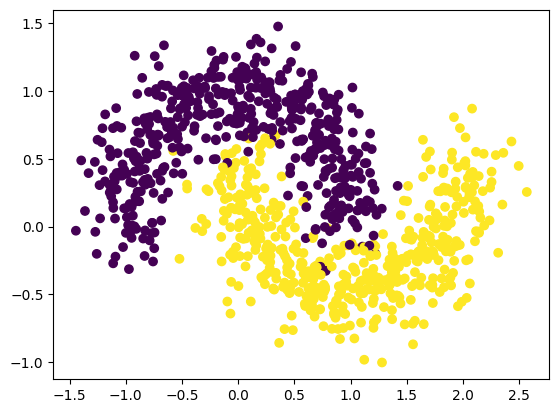

In [92]:
plt.scatter(X[:, 0], X[:, 1], c=y);

In [69]:
class MoonsModel(nn.Module):
  def __init__(self, in_feat, out_feat, hidden=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_feat, hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU(),
        nn.Linear(hidden, out_feat)
    )
  def forward(self, x):
    return self.linear_layer_stack(x)

NUM_FEATURES = 2
NUM_CLASS = 1

model = MoonsModel(NUM_FEATURES, NUM_CLASS, 10).to(device)

In [70]:
# loss & optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
accuracy_fn = Accuracy(task="binary", num_classes=NUM_CLASS)

In [72]:
# training and testing loop
epochs = 10000

for epoch in range(epochs):
  # training
  model.train()
  y_logits = model(X_train).squeeze()
  y_prob   = torch.sigmoid(y_logits)
  y_pred   = torch.round(y_prob)

  # loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred, y_train)

  # zero grad
  optimizer.zero_grad()

  # back propagation
  loss.backward()

  # optimizer step
  optimizer.step()

  # testing
  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_prob   = torch.sigmoid(test_logits)
    test_pred   = torch.round(test_prob)
    test_loss = loss_fn(test_logits, y_test)
    test_acc  = accuracy_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.3f} | Test loss: {test_loss:.3f} | Accuracy: {acc:.3f} | Test accuracy: {test_acc:.3f}")

Epoch: 0 | Loss: 0.365 | Test loss: 0.379 | Accuracy: 0.855 | Test accuracy: 0.835
Epoch: 100 | Loss: 0.343 | Test loss: 0.355 | Accuracy: 0.863 | Test accuracy: 0.840
Epoch: 200 | Loss: 0.326 | Test loss: 0.336 | Accuracy: 0.869 | Test accuracy: 0.850
Epoch: 300 | Loss: 0.313 | Test loss: 0.320 | Accuracy: 0.871 | Test accuracy: 0.855
Epoch: 400 | Loss: 0.303 | Test loss: 0.308 | Accuracy: 0.874 | Test accuracy: 0.865
Epoch: 500 | Loss: 0.295 | Test loss: 0.298 | Accuracy: 0.876 | Test accuracy: 0.875
Epoch: 600 | Loss: 0.289 | Test loss: 0.291 | Accuracy: 0.875 | Test accuracy: 0.875
Epoch: 700 | Loss: 0.284 | Test loss: 0.285 | Accuracy: 0.876 | Test accuracy: 0.875
Epoch: 800 | Loss: 0.280 | Test loss: 0.279 | Accuracy: 0.876 | Test accuracy: 0.875
Epoch: 900 | Loss: 0.276 | Test loss: 0.275 | Accuracy: 0.876 | Test accuracy: 0.875
Epoch: 1000 | Loss: 0.273 | Test loss: 0.271 | Accuracy: 0.877 | Test accuracy: 0.875
Epoch: 1100 | Loss: 0.270 | Test loss: 0.268 | Accuracy: 0.881 | T

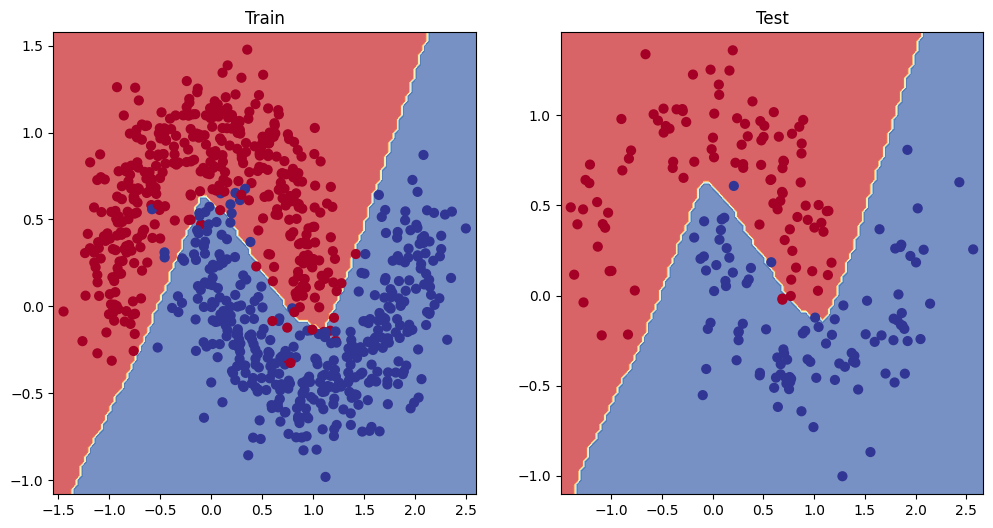

In [79]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)

plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

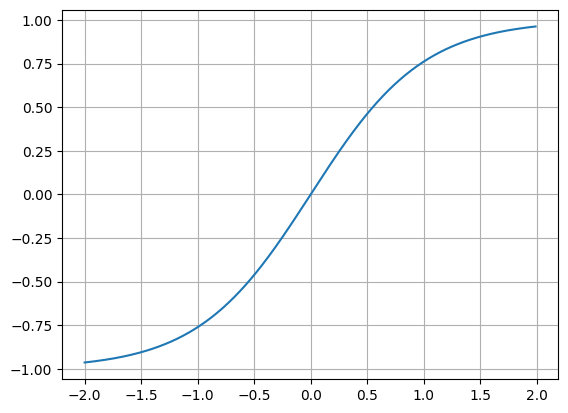

In [85]:
# tanh activation function
def tanh(z):
  return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))

z = np.arange(-2, 2, 0.01)
tanh_z = tanh(z)

plt.plot(z, tanh_z)
plt.grid();

# Multi-class Classification

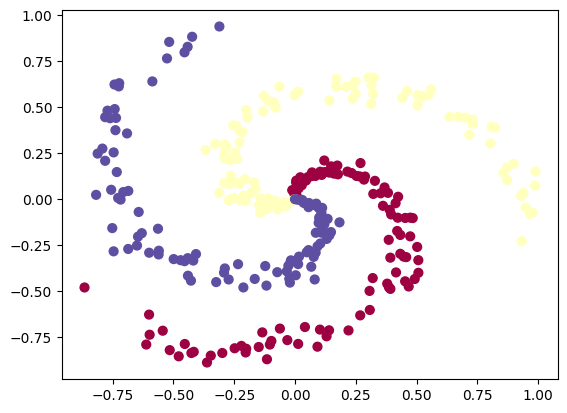

In [104]:
# data preparation
N = 100 # number points per class
D = 2 # dimension
K = 3 # number of class
X = np.zeros((N*K, D))
y = np.zeros(N*K, dtype="uint8")
for j in range(K):
  ix = range(N*j, N*(j + 1))
  r = np.linspace(0.0, 1, N) # radius
  t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N) *0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral);

In [105]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.2, random_state=42)

In [107]:
class SpiralsModel(nn.Module):
  def __init__(self, in_feat, out_feat, hidden=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_feat, hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU(),
        nn.Linear(hidden, out_feat)
    )
  def forward(self, x):
    return self.linear_layer_stack(x)

NUM_FEATURES = 2
NUM_CLASS = 3

model_1 = SpiralsModel(NUM_FEATURES, NUM_CLASS, 10).to(device)

In [108]:
# loss & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)
accuracy_fn = Accuracy(task="multiclass", num_classes=NUM_CLASS)

In [115]:
# training and testing loop
epochs = 10000

for epoch in range(epochs):
  # training
  model.train()
  y_logits = model_1(X_train)
  y_pred   = torch.softmax(y_logits, dim=1).argmax(dim=1)


  # loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred, y_train)

  # zero grad
  optimizer.zero_grad()

  # back propagation
  loss.backward()

  # optimizer step
  optimizer.step()

  # testing
  model.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test)
    test_pred   = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc  = accuracy_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.3f} | Test loss: {test_loss:.3f} | Accuracy: {acc:.3f} | Test accuracy: {test_acc:.3f}")

Epoch: 0 | Loss: 1.123 | Test loss: 1.152 | Accuracy: 0.350 | Test accuracy: 0.267
Epoch: 100 | Loss: 1.026 | Test loss: 1.036 | Accuracy: 0.562 | Test accuracy: 0.517
Epoch: 200 | Loss: 0.873 | Test loss: 0.885 | Accuracy: 0.646 | Test accuracy: 0.583
Epoch: 300 | Loss: 0.722 | Test loss: 0.753 | Accuracy: 0.625 | Test accuracy: 0.583
Epoch: 400 | Loss: 0.617 | Test loss: 0.659 | Accuracy: 0.646 | Test accuracy: 0.600
Epoch: 500 | Loss: 0.519 | Test loss: 0.556 | Accuracy: 0.708 | Test accuracy: 0.667
Epoch: 600 | Loss: 0.429 | Test loss: 0.451 | Accuracy: 0.788 | Test accuracy: 0.767
Epoch: 700 | Loss: 0.351 | Test loss: 0.359 | Accuracy: 0.829 | Test accuracy: 0.817
Epoch: 800 | Loss: 0.290 | Test loss: 0.292 | Accuracy: 0.883 | Test accuracy: 0.867
Epoch: 900 | Loss: 0.243 | Test loss: 0.240 | Accuracy: 0.908 | Test accuracy: 0.867
Epoch: 1000 | Loss: 0.206 | Test loss: 0.200 | Accuracy: 0.917 | Test accuracy: 0.917
Epoch: 1100 | Loss: 0.176 | Test loss: 0.168 | Accuracy: 0.946 | T

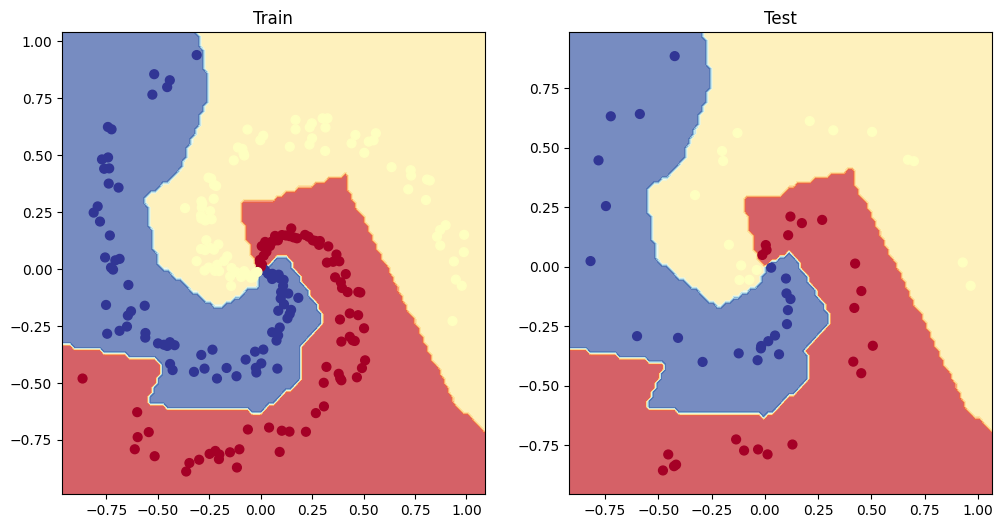

In [116]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(122)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)